# Exploratory Data Analysis of Movie Ratings
Analysis of 449 movies using IMDb, Rotten Tomatoes, Letterboxd, Metacritic, and audience ratings.

## Importing Libraries
   Dfifferent Libraries are imported for data manupulation , numerical operation and data visualization.

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

## Loading the dataset 


In [2]:
df=pd.read_csv(r"C:\Users\garim\OneDrive\Desktop\github projects\data cleaning with python\Movie Dataset Cleaning Project\Cleaned_Movie_Dataset.csv")

## Setting option 
Using global function 'set_option', provided by pandas to control display.

In [4]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_colwidth",None)

## Data Overview  
Before starting the analysis, it’s important to understand the dataset size, available columns, overall structure, and data types.

In [5]:
# Previewing First Few rows to understand the Data structure. 
df.head()

,rank,title,year,genre,language,flickmetrix_score,imdb_100,imdb_votes,metacritic,critic_rating_rt,critic_reviews,audience_rating,audience_reviews,letterboxd,letterboxd_votes,google_score,imdbid,custom_score,score_diff
0,1,the godfather,1972,drama crime,english,93.0,92.0,2108796,100.0,96.0,104,95.0,1087289,90,1789555,90.0,tt0068646,93.83,1.0
1,2,seven samurai,1954,action drama,japanese,93.0,86.0,381712,98.0,97.0,68,94.0,167123,92,318537,93.0,tt0047478,93.33,3.0
2,3,12 angry men,1957,drama,english,92.0,90.0,917215,97.0,93.0,58,94.0,376697,92,917590,91.0,tt0050083,92.83,1.0
3,4,schindlers list,1993,drama history war,english,92.0,90.0,1512905,95.0,93.0,82,94.0,601555,90,978054,93.0,tt0108052,92.50,1.0
4,5,the godfather part ii,1974,drama crime,english,92.0,90.0,1420179,90.0,95.0,80,94.0,586600,92,934120,89.0,tt0071562,91.67,1.0


In [6]:
# To understand the shape of dataset i.e Number of rows and columns.
df.shape

(449, 19)

In [8]:
#To Understand the datatype.
df.dtypes

rank                   int64
title                 object
year                   int64
genre                 object
language              object
flickmetrix_score    float64
imdb_100             float64
imdb_votes             int64
metacritic           float64
critic_rating_rt     float64
critic_reviews         int64
audience_rating      float64
audience_reviews       int64
letterboxd             int64
letterboxd_votes       int64
google_score         float64
imdbid                object
custom_score         float64
score_diff           float64
dtype: object

In [9]:
# Check for missing values.
df.isnull().sum()

rank                 0
title                0
year                 0
genre                0
language             0
flickmetrix_score    0
imdb_100             0
imdb_votes           0
metacritic           0
critic_rating_rt     0
critic_reviews       0
audience_rating      0
audience_reviews     0
letterboxd           0
letterboxd_votes     0
google_score         0
imdbid               0
custom_score         0
score_diff           0
dtype: int64

## Summary Statistics  
After the dataset overview, we examine summary statistics to understand measures of central tendency (mean, median, mode) and detect skewness in the data distribution.


In [11]:
# Using function 'describe()' to get summary statistics for numerical columns.
df.describe()

,rank,year,flickmetrix_score,imdb_100,imdb_votes,metacritic,critic_rating_rt,critic_reviews,audience_rating,audience_reviews,letterboxd,letterboxd_votes,google_score,custom_score,score_diff
count,449.000000,449.000000,449.000000,449.000000,4.490000e+02,449.000000,449.000000,449.000000,449.000000,4.490000e+02,449.000000,4.490000e+02,449.000000,449.000000,449.000000
mean,225.000000,1994.151448,83.884187,79.694878,4.315229e+05,86.761693,85.581292,122.926503,85.881960,8.020289e+05,82.151448,7.022965e+05,85.808463,84.229866,4.977728
std,129.759393,25.683153,2.685102,3.599106,4.723575e+05,6.822936,4.844751,67.931731,4.757687,3.155288e+06,3.954457,7.568636e+05,5.441148,2.798203,4.095887
min,1.000000,1920.000000,80.000000,71.000000,1.194000e+04,65.000000,72.000000,50.000000,57.000000,1.759300e+04,68.000000,3.153500e+04,46.000000,77.000000,0.000000
25%,113.000000,1976.000000,82.000000,77.000000,1.019410e+05,82.000000,82.000000,70.000000,84.000000,7.854000e+04,80.000000,1.434130e+05,83.000000,82.170000,2.000000
50%,225.000000,2003.000000,83.000000,80.000000,2.312560e+05,87.000000,85.000000,100.000000,87.000000,1.982740e+05,82.000000,3.962560e+05,86.000000,83.670000,4.000000
75%,337.000000,2015.000000,85.000000,82.000000,6.460640e+05,91.000000,89.000000,156.000000,89.000000,5.782800e+05,84.000000,9.983530e+05,90.000000,86.000000,7.000000
max,449.000000,2025.000000,93.000000,92.000000,2.666368e+06,100.000000,98.000000,342.000000,95.000000,2.454920e+07,92.000000,3.771374e+06,98.000000,93.830000,29.000000


In [14]:
# Categorical variables are summerized to identify dominant categories and data diversity. 
df.describe(include='object')



,title,genre,language,imdbid
count,449,449,449,449
unique,448,228,26,449
top,all quiet on the western front,drama,english,tt5727208
freq,2,56,334,1


#### Summary Statistics Analysis  

- The dataset spans movies released between 1920 and 2025. The mean release year (1994) is lower than the median release year (2003), which indicates that older films are pulling the average downward and highlights the presence of both classic and modern movies.  

- IMDb votes, critic reviews, audience reviews, and Letterboxd votes all show positively skewed distributions. This means that while most films receive moderate levels of engagement, a small number of blockbuster movies dominate with exceptionally high vote and review counts. Audience reviews are especially dispersed, reflecting blockbuster‑level popularity.  

- Metacritic scores demonstrate relatively low variability, with mean and median values being very close. This suggests that critic ratings are fairly balanced across the dataset, without extreme differences in evaluation.  

- Audience ratings are generally high and consistent. The small difference between mean and median values, along with a low standard deviation, indicates that viewers tend to rate these movies favorably and with relatively little variation.  

- The difference between critic and audience scores is generally small, as reflected by the close mean and median values. This shows that critics and audiences tend to agree on the quality of most movies, although a few films reveal notable disagreements.  

#####                                     Categorical Variables  

-  Titles → 449 records but only 448 unique titles, suggesting a duplicate or shared name.  
-  Genres → 228 unique genre combinations; Drama dominates with 56 movies.  
-  Languages→ 26 languages represented; English overwhelmingly leads, reflecting dominance of English‑language cinema.  
-  IMDb IDs → Each record has an IMDb ID, ensuring unique identification and reliable cross‑referencing.

## Distribution Analysis  



### IMDb Votes (Histogram)
To Examine distribution of votes by audience, we plot a Histogram for 'IMDb Vote' column. It will help understand the pattern and distribution of votes among movies. 

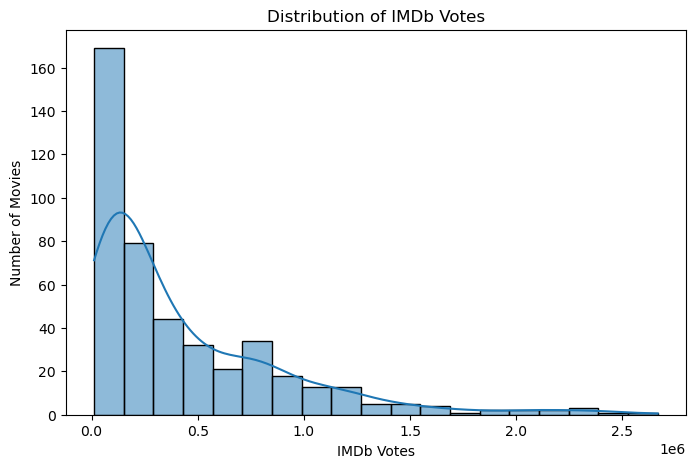

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["imdb_votes"],kde=True)
plt.title("Distribution of IMDb Votes")
plt.xlabel("IMDb Votes")
plt.ylabel("Number of Movies")
plt.show()

The distribution of IMDb vote counts is strongly positively skewed. Most movies receive relatively low to moderate numbers of votes, while a small number of highly popular movies attract exceptionally large vote counts. The long right tail indicates the presence of blockbuster films with significantly higher audience engagement than the majority of movies in the data.

### Year (Histogram)
To explore the distribution of movie release years and identify which era dominates the dataset, we plot a histogram of the `Year` column. This visualization helps reveal patterns across decades, showing whether classic films or more recent releases are more prevalent in the collection.

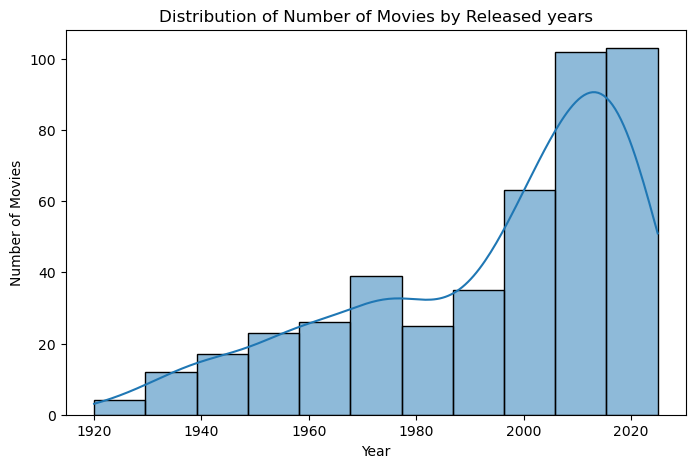

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['year'],kde=True)
plt.title("Distribution of Number of Movies by Released years")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

The distribution of release years is negatively skewed, with most movies concentrated in recent decades and a smaller number of films originating from earlier periods. The dataset spans more than a century of cinema, ranging from 1920 to 2025, but the highest concentration of movies is observed after 2000. This indicates that modern films are more strongly represented than classic films.

## Outlier Analysis  


### IMDb Votes 
This section identify potential Outliers in column 'IMDb Votes" using boxplot.

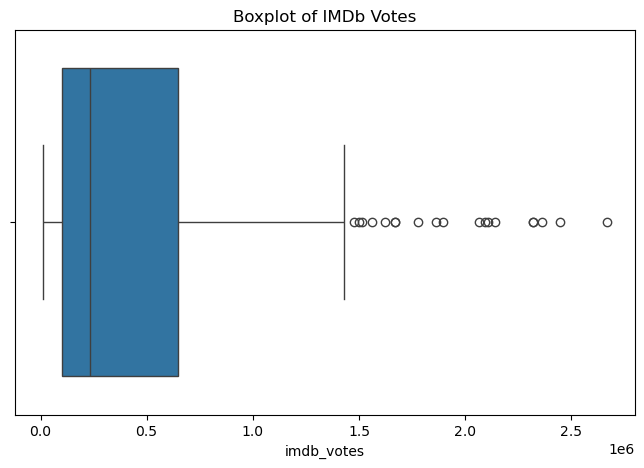

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["imdb_votes"])
plt.title("Boxplot of IMDb Votes")
plt.show()

The boxplot of IMDb Votes indicates a strongly right-skewed distribution. The median is closer to the lower quartile (Q1), suggesting that the upper half of the data is more spread out than the lower half. Several high-value outliers are present beyond the upper whisker, indicating that a small number of movies have exceptionally high vote counts. These outliers likely represent highly popular blockbuster films rather than data errors.

### Audience Review 
A Boxplot is used to identify potential outliers in audience review columns.

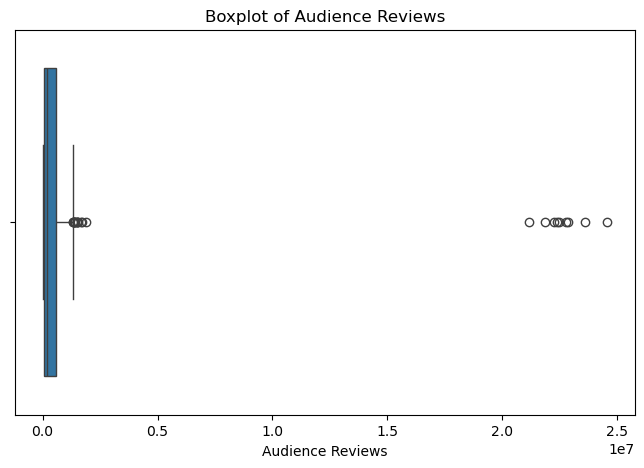

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["audience_reviews"])
plt.title("Boxplot of Audience Reviews")
plt.xlabel("Audience Reviews")
plt.show()

The boxplot of Audience Reviews shows a strongly right-skewed distribution with several extreme high-value outliers. These outliers likely correspond to highly popular blockbuster movies that received substantially more audience reviews than the majority of films. The median is positioned closer to Q1 than Q3, indicating that the upper half of the data is more spread out. This suggests that while most movies receive a moderate number of audience reviews, a small number of films attract exceptionally large audience engagement.

## Categorical Analysis 


### Language (Bar Graph)
The bar Graph shows frequency of each language in the dataset. It helps in identify dominate Language and compare distribution of movies across different language.

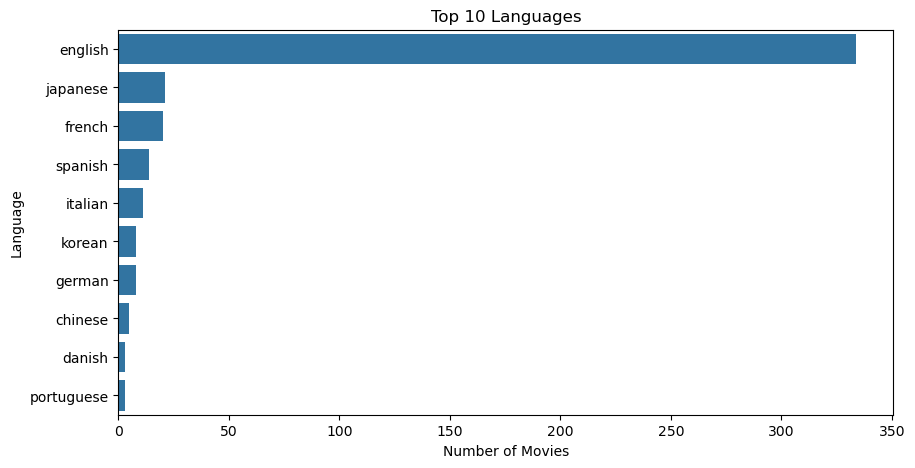

In [26]:
top_lang = df["language"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x = top_lang.values , y = top_lang.index)
plt.title("Top 10 Languages")
plt.xlabel("Number of Movies")
plt.ylabel("Language")
plt.show()


The graph highlights the top 10 most frequently used languages in the dataset 
English clearly dominates, making it the most prevalent language across the records.


### Genre ( Bar Graph)
The bar graph visualize number of movies in each Genre category to identify dominate Genre in the dataset.

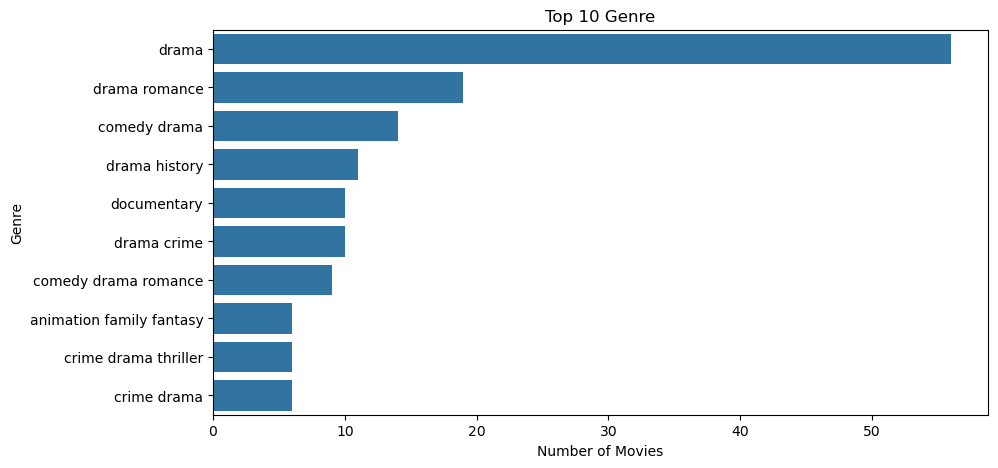

In [27]:
top_genre = df["genre"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genre.values , y=top_genre.index)
plt.title("Top 10 Genre")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()


Drama is the most common genre, appearing approximately 56 times, making it the dominant genre in the dataset.Several of the top genres contain Drama as a component (e.g., Drama Romance, Drama History, Drama Crime, Drama War), indicating that drama is a recurring theme among highly rated movies.

## Relationship Analysis

This section explores the relationship between numerical variables in the dataset. A correlation heatmap is used to measure the strength of relationships between variables, while scatter plots help visualize these relationships and identify patterns or trends.

### Correlation Heatmap

A correlation heatmap visualizes the relationship between numerical variables. Correlation values closer to **+1** indicate a strong positive relationship, while values closer to **-1** indicate a strong negative relationship. Values near **0** indicate little or no relationship. Darker colors represent stronger correlations, with **red** showing positive correlations and **blue** showing negative correlations.


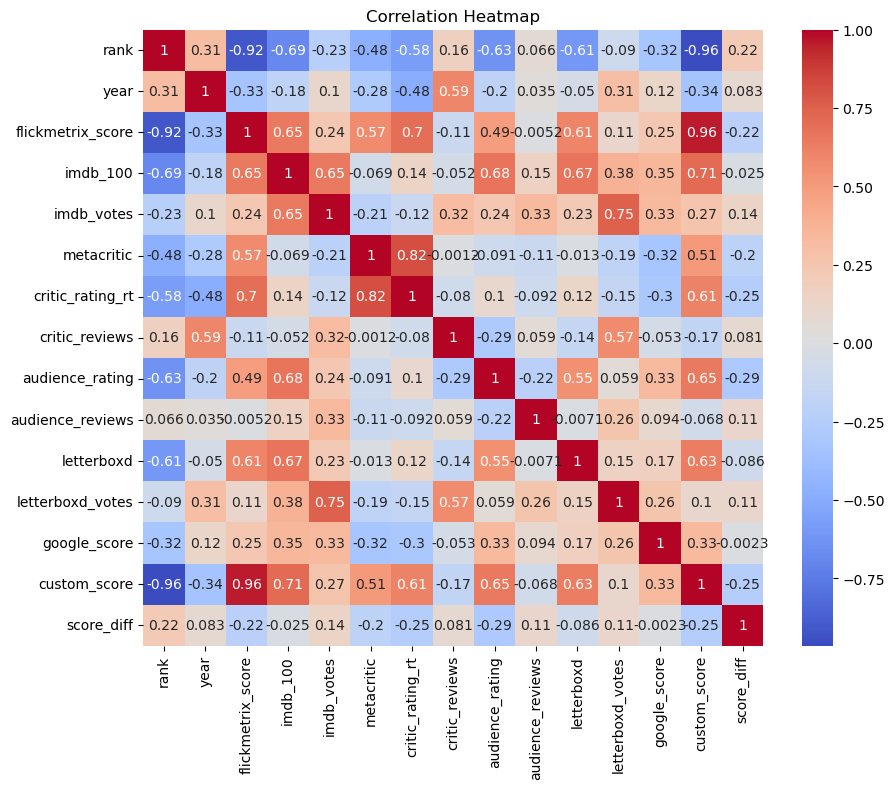

In [31]:
corr = df.select_dtypes(include= "number").corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
                        

- **Flickmetrix Score vs. Custom Score** → Very strong positive correlation (0.96), indicating both metrics capture movie quality in a highly similar way.  

- **Metacritic vs. Rotten Tomatoes Critic Rating** → Strong positive correlation (0.82), showing substantial agreement among critics across different platforms.  

- **IMDb Votes vs. Letterboxd Votes** → Strong positive correlation (0.75), suggesting that movies popular on one platform tend to also be popular on the other.  

- **IMDb Rating vs. Audience Rating** → Moderately strong positive correlation (0.68), reflecting that audience opinions are generally consistent across rating platforms.  

- **Rank vs. Custom Score** → Very strong negative correlation (-0.96), meaning movies with higher scores tend to achieve better ranks (lower rank numbers).


### Scatterplot: IMDb Votes vs. IMDb Rating 
This scatter plot shows the relationship between **IMDb Votes** and **IMDb Rating**. It helps identify whether movies with more IMDb votes tend to have higher ratings and reveals any patterns or outliers.

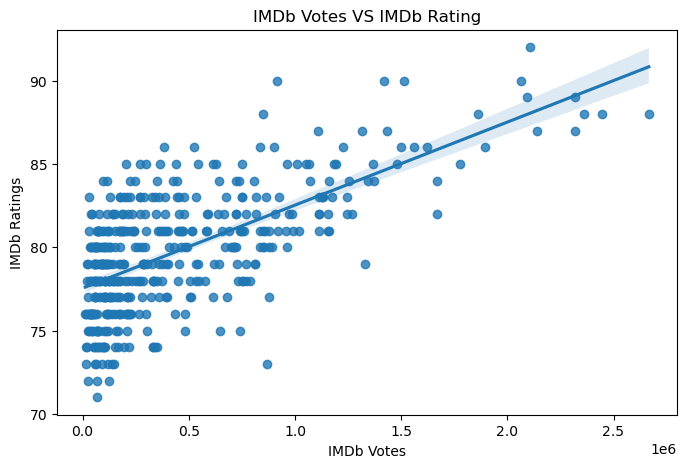

In [32]:
plt.figure(figsize=(8,5))
sns.regplot(x=df["imdb_votes"],y=df["imdb_100"])
plt.title("IMDb Votes VS IMDb Rating")
plt.xlabel("IMDb Votes")
plt.ylabel("IMDb Ratings")
plt.show()
            


- The scatterplot reveals a **moderate positive relationship** between IMDb Votes and IMDb Rating, suggesting that movies with more votes often achieve higher ratings.  
- Movies with a larger number of votes generally tend to have higher IMDb ratings, indicating that popularity and perceived quality are somewhat aligned.  
- The majority of movies are concentrated below **1 million votes**, with ratings typically falling between **74 and 84**, showing where most films cluster.  
- A few highly popular movies receive more than **2 million votes** and also maintain high ratings, highlighting blockbuster films with strong audience approval.  


## Time Trend Analysis

This section analyzes how the number of movies changes over time. It helps identify trends in movie releases and highlights periods with higher or lower production.

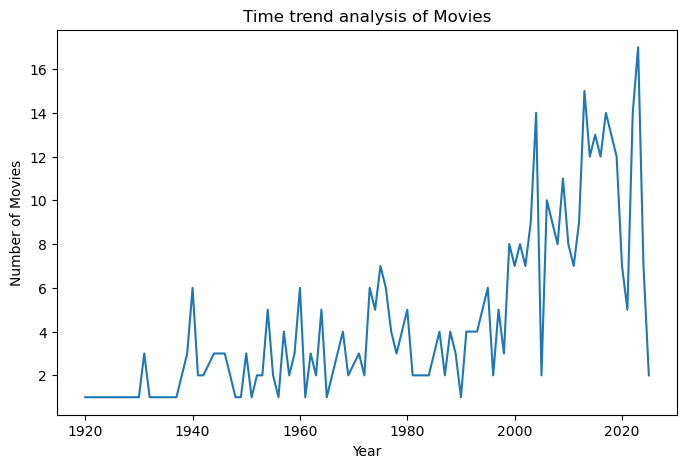

In [33]:
movie_per_year = df.groupby('year').size()
plt.figure(figsize=(8,5))
sns.lineplot(x=movie_per_year.index , y = movie_per_year.values)
plt.title("Time trend analysis of Movies")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()


- The line plot shows an overall upward trend in the number of movies over time.
- The dataset contains relatively few movies from the early decades (1920–1960).
- The number of movies increases noticeably after the 1990s, with the highest concentration in recent years.
- This suggests the dataset is dominated by modern movies while still including a selection of older classics.

## Top Movies Analysis

This section identifies the top-performing movies in the dataset based on ratings and popularity. It helps compare movies using different performance metrics and highlights the films that stand out in terms of audience appreciation and engagement.

### 1. Top 10 IMDb Rated Movies

This displays the top 10 movies with the highest IMDb ratings in a bar graph and table format. 

In [38]:
# Table 
top_rated = df.nlargest(10,"imdb_100").sort_values("imdb_100")
top_rated[["title","year","imdb_100"]]

,title,year,imdb_100
12,the good the bad and the ugly,1966,88.0
61,the lord of the rings the two towers,2002,88.0
102,forrest gump,1994,88.0
6,pulp fiction,1994,89.0
32,the lord of the rings the fellowship of the ring,2001,89.0
4,the godfather part ii,1974,90.0
3,schindlers list,1993,90.0
2,12 angry men,1957,90.0
27,the lord of the rings the return of the king,2003,90.0
0,the godfather,1972,92.0


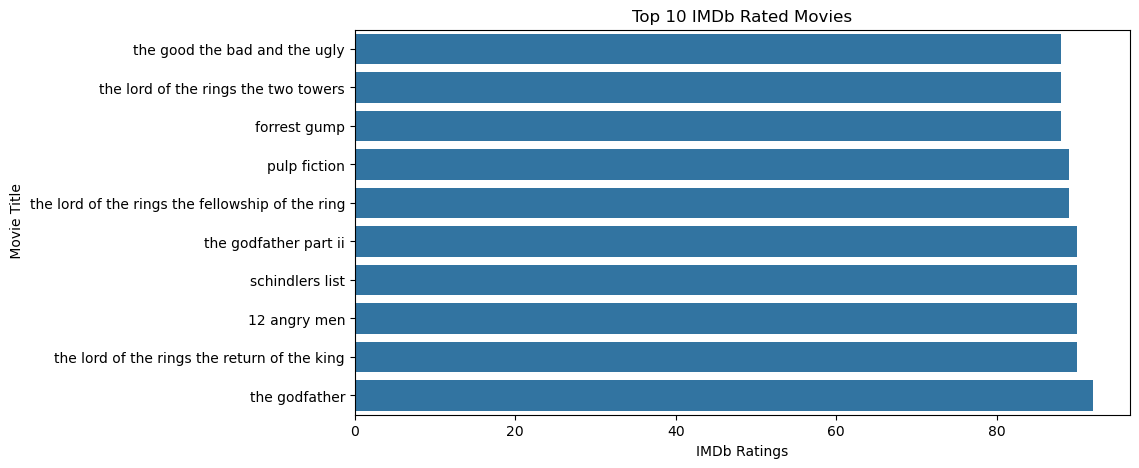

In [40]:
# Bar Graph
plt.figure(figsize=(10,5))
sns.barplot(data=top_rated,x="imdb_100",y="title")
plt.title("Top 10 IMDb Rated Movies")
plt.xlabel("IMDb Ratings")
plt.ylabel(" Movie Title")
plt.show()


The movie *The Godfather* (1972) holds the highest IMDb rating of 92.0.  
Several sequels, such as *The Godfather Part II* and *The Lord of the Rings* series, also achieve similarly high audience ratings.


### Most Popular Movies by IMDb Votes

This Table and bar graph displays the top 10 movies with the highest IMDb vote counts. It helps identify the most popular movies based on audience engagement.

In [42]:
# Table
most_popular= df.nlargest(10,"imdb_votes").sort_values("imdb_votes")
most_popular[["title","year","imdb_votes"]]

,title,year,imdb_votes
322,se7en,1995,1895482
27,the lord of the rings the return of the king,2003,2064721
32,the lord of the rings the fellowship of the ring,2001,2094033
0,the godfather,1972,2108796
332,the matrix,1999,2141445
265,interstellar,2014,2317550
6,pulp fiction,1994,2319136
102,forrest gump,1994,2362620
271,fight club,1999,2444413
215,inception,2010,2666368


Text(0, 0.5, 'Movie Title')

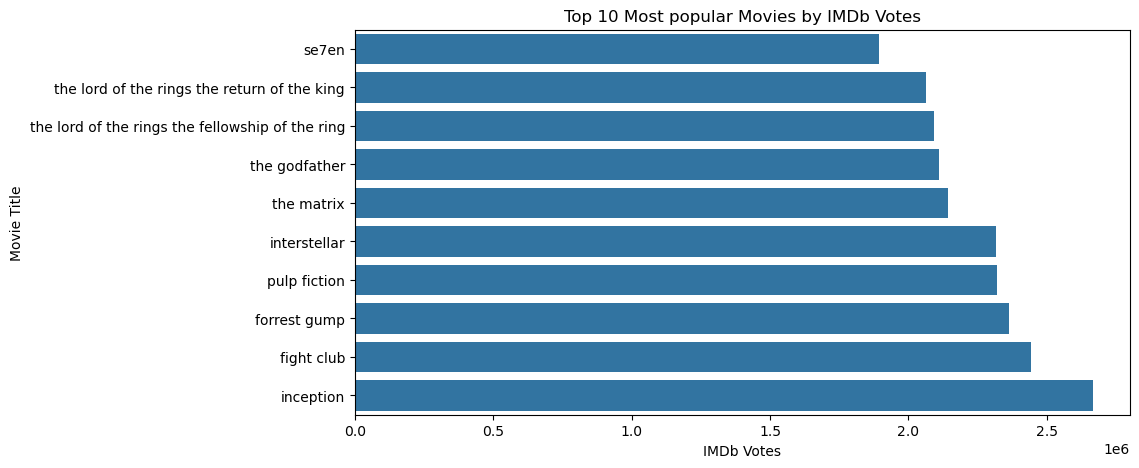

In [43]:
# Bar Graph 
plt.figure(figsize=(10,5))
sns.barplot(data=most_popular, x ="imdb_votes",y="title")
plt.title("Top 10 Most popular Movies by IMDb Votes")
plt.xlabel("IMDb Votes")
plt.ylabel("Movie Title")


The top 10 most popular movies by IMDb votes include a mix of both classic and modern films.
*Inception* (2010) leads with over 2.6 million votes, highlighting its exceptional popularity 
The *Lord of the Rings* sequels appear twice in the list, reinforcing the franchise’s strong audience appeal.


## Key Insights

- The dataset contains **449 movies** with **19 features** describing ratings, reviews, genres, languages, and popularity.
- **English** is the dominant language, representing the majority of movies in the dataset.
- **Drama** is the most common genre, followed by other popular genres such as Crime and Comedy.
- IMDb Votes and Audience Reviews are **positively skewed**, with a few blockbuster movies receiving exceptionally high engagement.
- Boxplots reveal several **outliers** in IMDb Votes and Audience Reviews, indicating movies with extraordinary popularity.
- The correlation heatmap shows a **strong positive relationship** between Flickmetrix Score and Custom Score, suggesting that both scoring systems evaluate movies similarly.
- The scatter plot indicates a **moderate positive relationship** between IMDb Votes and IMDb Rating, showing that more popular movies often receive higher ratings, although there are exceptions.
- The number of movie releases generally shows an **upward trend** over the years.
- The top-rated and most popular movies are not always the same, indicating that **critical acclaim and popularity do not always align**.

## Conclusion

This exploratory data analysis helped understand the characteristics of the movie dataset by examining distributions, outliers, categories, relationships, trends, and top-performing movies. The findings revealed clear patterns in movie popularity and ratings, identified dominant genres and languages, and highlighted strong correlations between several scoring metrics. Overall, the dataset is well-suited for further analysis, visualization, and machine learning tasks.